# Puntos 2, 3 y 4: Estrategia de análisis, desarrollo y generación de resultados

Este notebook desarrolla los puntos 2, 3 y 4 del Taller 1 de MINE-4101. Parte de los
datos ya tratados en 01_entendimiento_inicial.ipynb, que debe ejecutarse primero para
generar data/secop_bienes_limpio.parquet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

df_limpio = pd.read_parquet('../data/secop_bienes_limpio.parquet')
print(df_limpio.shape)

(196391, 41)


## 2. Estrategia de análisis

La estrategia parte de los tres hallazgos cuantificados en el punto 1, el 9.51% de los
contratos tuvo adición de plazo, con una cola de extensiones que llega hasta 874 días
una vez corregidos los errores de fecha, el 21.79% de todos los contratos terminó o se
cerró sin haber ejecutado ni un peso del presupuesto comprometido, y el 55.31% de los
contratos cerrados o terminados no está liquidado. Estas tres cifras son la variable de
salida que se quiere explicar, y la pregunta central de la estrategia es qué
características del contrato, como su valor, la modalidad de contratación, el sector, o
el destino del gasto, se asocian con que un contrato caiga en alguno de estos tres
grupos de riesgo. Para responder esto se sigue una progresión de menor a mayor
complejidad, empezando por estadísticos descriptivos y proporciones por grupo, por
ejemplo el porcentaje de contratos sin liquidar dentro de cada modalidad de
contratación o de cada sector, siguiendo con pruebas de hipótesis formales que
confirmen si esas diferencias observadas son estadísticamente significativas o podrían
deberse al azar, y cerrando con visualizaciones que crucen varios atributos al tiempo
para ver combinaciones de características, no solo variables aisladas.

La elección de la prueba depende del tipo de variable, del número de grupos que se
comparan, y de si se cumplen los supuestos de normalidad. Para variables numéricas como
dias_adicionados o valor_del_contrato, que la revisión inicial del punto 1 ya mostró con
distribuciones extremadamente sesgadas y una alta concentración de ceros, se usa la
prueba de Kruskal-Wallis cuando se comparan más de dos grupos, como las 9 modalidades de
contratación, y la prueba de Mann-Whitney U cuando se comparan dos grupos puntuales, por
ejemplo contratos liquidados frente a no liquidados, o dos modalidades específicas de
interés para la focalización. Para las tres señales de desviación, que son
esencialmente proporciones, contrato con o sin liquidar, con o sin ejecución de
presupuesto, se usa la prueba de chi cuadrado de independencia contra variables
categóricas como modalidad de contratación, sector o destino del gasto, verificando
primero que las frecuencias esperadas sean suficientes para que la prueba sea válida.
En todos los casos se revisan los supuestos antes de interpretar el resultado, y se
reporta el tamaño del efecto, eta cuadrado o Cramér's V según el caso, además del valor
p, porque una asociación puede ser estadísticamente significativa con un tamaño de
muestra grande como este y aun así ser irrelevante en la práctica. Antes de cada prueba
se define además qué diferencia sería lo suficientemente grande como para justificar un
cambio en la estrategia de supervisión, para no basar la decisión únicamente en si el p
valor cruza el umbral de 0.05. La parte visual de la estrategia no se limita a graficar
una variable a la vez, incluye cruces de al menos tres atributos, por ejemplo el valor
del contrato contra la modalidad de contratación, diferenciando además por si el
contrato quedó liquidado o no, para identificar visualmente qué combinaciones concentran
el mayor riesgo. Todo este análisis se hace sobre las columnas ya marcadas como
confiables en el punto 1, respetando las banderas de calidad construidas.

## 3. Desarrollo de la estrategia

### 3.1 ¿La modalidad de contratación se asocia con adiciones de plazo más largas?

**Paso 0. Umbral de relevancia práctica.** Antes de probar nada, se define qué
diferencia importaría en la práctica. Una diferencia de al menos 15 días entre
modalidades se considera relevante para la estrategia de supervisión, aproximadamente
la mitad de la mediana de 31 días que se observó en el punto 1 para los contratos que
sí tuvieron adición.

**Paso 1. Hipótesis.**
H0: la distribución de dias_adicionados es la misma en las 9 modalidades de contratación.
H1: al menos una modalidad tiene una distribución distinta, con valores que tienden a ser más altos o más bajos.

In [2]:
from scipy import stats

resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion')['dias_adicionados'].agg(['count', 'mean', 'median', 'std']).round(2)
print(resumen_modalidad.sort_values('median', ascending=False))

                                                     count   mean  median  \
modalidad_de_contratacion                                                   
Contratación Directa (con ofertas)                    5001   5.54     0.0   
Contratación directa                                  3938   5.35     0.0   
Contratación régimen especial                        19250   3.67     0.0   
Contratación régimen especial (con ofertas)           6154  14.21     0.0   
Licitación pública                                    2330  18.65     0.0   
Mínima cuantía                                      117752   2.93     0.0   
Selección Abreviada Menor Cuantía Sin Manifesta...     236  17.74     0.0   
Selección Abreviada de Menor Cuantía                  8822   8.35     0.0   
Selección abreviada subasta inversa                  32907   9.60     0.0   

                                                      std  
modalidad_de_contratacion                                  
Contratación Directa (con oferta

**Paso 2. Verificación de supuestos.** El punto 1 ya mostró que dias_adicionados tiene
el 90.49% de sus valores en cero, una distribución completamente alejada de la
normalidad que requiere ANOVA. Por eso, en vez de forzar ANOVA, se usa Kruskal-Wallis,
la alternativa no paramétrica que compara las distribuciones de más de dos grupos sin
asumir normalidad.

**Paso 3. Prueba adecuada y cálculo.**

In [3]:
grupos = [g['dias_adicionados'].dropna().values for _, g in df_limpio.groupby('modalidad_de_contratacion')]
h_stat, p_value = stats.kruskal(*grupos)

print('Kruskal-Wallis: H =', h_stat, ', p =', p_value)

Kruskal-Wallis: H = 4327.167710039168 , p = 0.0


**Paso 4. Tamaño del efecto.**

In [4]:
k = df_limpio['modalidad_de_contratacion'].nunique()
n = df_limpio['dias_adicionados'].notna().sum()
eta_cuadrado = (h_stat - k + 1) / (n - k)
print('Numero de grupos:', k, ', tamano de muestra:', n)
print('Tamaño del efecto (eta cuadrado):', round(eta_cuadrado, 4))

Numero de grupos: 9 , tamano de muestra: 196390
Tamaño del efecto (eta cuadrado): 0.022


**Paso 5. Comparación puntual entre los dos extremos.** Con 9 modalidades hay 36
comparaciones posibles, pero la más relevante para la estrategia es la de los dos
extremos, Licitación pública contra Mínima cuantía, que concentra además la mayoría de
los contratos (59.96%). Como las medianas son cero en ambas por la concentración de
ceros, se usa Mann-Whitney U en vez de comparar solo promedios, que no asume
normalidad y compara si una distribución tiende a tener valores más altos que la otra.

In [5]:
licitacion = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Licitación pública', 'dias_adicionados'].dropna()
minima = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Mínima cuantía', 'dias_adicionados'].dropna()

u_stat, p_valor_par = stats.mannwhitneyu(licitacion, minima, alternative='two-sided')

print('Mann-Whitney U (Licitación pública vs Mínima cuantía): U =', u_stat, ', p =', p_valor_par)
print('Diferencia de promedios:', round(licitacion.mean() - minima.mean(), 2), 'días')

Mann-Whitney U (Licitación pública vs Mínima cuantía): U = 163548994.5 , p = 1.183259727587737e-264
Diferencia de promedios: 15.72 días


**Paso 6. Interpretación.**

El tamaño del efecto general (eta cuadrado = 0.022) es pequeño, la modalidad de
contratación como factor completo explica apenas el 2.2% de la variación en
dias_adicionados entre las 196390 filas con dato. Esto significa que, en general, la
modalidad no es un buen predictor aislado de cuánto se adiciona un contrato.

Sin embargo, la comparación puntual entre los dos extremos sí es relevante en la
práctica. Licitación pública tiene un promedio de adición de 18.65 días frente a 2.93
días en Mínima cuantía, una diferencia de 15.72 días que supera el umbral de 15 días
definido antes de la prueba, y la diferencia es además estadísticamente significativa
(Mann-Whitney U, p menor a 0.001). Esto no contradice el tamaño del efecto pequeño, lo
complementa, el efecto general es pequeño porque la mayoría de las modalidades se
parecen entre sí cerca del promedio general, pero Licitación pública en particular sí
se separa de forma relevante del resto, en especial de Mínima cuantía, que concentra el
59.96% de todos los contratos.

En conclusión, la modalidad de contratación por sí sola no es un criterio fuerte de
focalización para dias_adicionados, pero Licitación pública sí muestra una tendencia
consistente a adiciones de plazo más largas, y debería considerarse como un factor
adicional dentro de un criterio compuesto de supervisión, no como el único criterio.

### 3.2 ¿La modalidad de contratación se asocia con presupuesto no ejecutado?

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al
menos 10 puntos porcentuales entre modalidades en la proporción de contratos cerrados
o terminados sin ejecutar presupuesto, dado que la tasa general ya es alta, 21.79% de
todos los contratos.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin ejecutar presupuesto es independiente de la
modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [6]:
df_limpio['no_ejecutado'] = df_limpio['estado_contrato'].isin(['Terminado', 'Cerrado']) & (df_limpio['valor_pagado'] == 0)

tabla_ejecucion = pd.crosstab(df_limpio['modalidad_de_contratacion'], df_limpio['no_ejecutado'])
print(tabla_ejecucion)
print()
proporciones = (pd.crosstab(df_limpio['modalidad_de_contratacion'], df_limpio['no_ejecutado'], normalize='index') * 100).round(2)
print(proporciones)

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   3780   1221
Contratación directa                                 2958    980
Contratación régimen especial                       14066   5184
Contratación régimen especial (con ofertas)          3776   2378
Licitación pública                                   1856    474
Mínima cuantía                                      94137  23616
Selección Abreviada Menor Cuantía Sin Manifesta...    179     57
Selección Abreviada de Menor Cuantía                 6567   2255
Selección abreviada subasta inversa                 26277   6630

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                  75.58  24.42
Contratación directa                                75.11  24.89
Contratación régimen esp

**Paso 2 y 3. Supuestos y prueba.** Para chi cuadrado de independencia se requiere que
las frecuencias esperadas sean de al menos 5 en cada celda. Se verifica antes de
interpretar el resultado, y se calcula también Cramér's V como tamaño del efecto, dado
que con un tamaño de muestra tan grande el p valor por sí solo tiende a salir
significativo.

In [7]:
chi2, p_value, dof, esperadas = stats.chi2_contingency(tabla_ejecucion)
print('Chi2 =', chi2, ', p =', p_value, ', grados de libertad =', dof)
print('Minima frecuencia esperada:', esperadas.min())

n = tabla_ejecucion.values.sum()
k_min = min(tabla_ejecucion.shape) - 1
cramers_v = (chi2 / (n * k_min)) ** 0.5
print('Cramér V:', round(cramers_v, 4))

Chi2 = 1703.3925485007555 , p = 0.0 , grados de libertad = 8
Minima frecuencia esperada: 51.4260836800057
Cramér V: 0.0931


**Paso 4. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 1703.39, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente significativa entre `modalidad_de_contratacion` y `no_ejecutado`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 51.43).

El tamaño del efecto, Cramér's V = 0.0931, está por debajo de 0.10, el umbral que Cohen propone para un efecto pequeño en esta tabla, es decir, es un efecto despreciable. Esto significa que en términos globales `modalidad_de_contratacion` explica muy poco de la variabilidad en si un contrato queda con presupuesto no ejecutado.

Ese resultado agregado esconde un patrón puntual relevante. La mayoría de las modalidades se agrupan alrededor de 20% de contratos no ejecutados (`Mínima cuantía` 20.06%, `Licitación pública` 20.34%, `Selección abreviada subasta inversa` 20.15%), pero `Contratación régimen especial (con ofertas)` se aleja de ese grupo con 38.64%, casi el doble. La diferencia entre este último grupo y el resto es de aproximadamente 18.5 puntos porcentuales, una brecha que supera claramente el umbral de 10 puntos definido en el Paso 0.

En conclusión, `modalidad_de_contratacion` por sí sola no es un buen predictor general de `no_ejecutado` (efecto pequeño), pero identifica una modalidad puntual, `Contratación régimen especial (con ofertas)`, que representa un factor de riesgo accionable para el criterio de focalización.

Con esto se cierra la segunda pregunta del Punto 3.

### 3.3 ¿La modalidad de contratación se asocia con el cierre sin liquidar?

Analizamos la tercera señal de desviación identificada en el Punto 1 (55.31% de contratos cerrados o terminados sin liquidar) contra `modalidad_de_contratacion`, siguiendo la misma lógica de umbral de relevancia práctica, prueba estadística y tamaño del efecto usada en 3.1 y 3.2.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre modalidades.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente de la modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [8]:
# Paso 2. Subconjunto: contratos cerrados o terminados, respetando la bandera de calidad liquidacion_confiable
sub_liquidacion = df_limpio[
    (df_limpio['estado_contrato'].isin(['Cerrado', 'Terminado'])) &
    (df_limpio['liquidacion_confiable'])
].copy()

print(f"Contratos cerrados/terminados con liquidaci_n confiable: {len(sub_liquidacion)}")
print(sub_liquidacion['liquidaci_n'].value_counts())

Contratos cerrados/terminados con liquidaci_n confiable: 101054
liquidaci_n
No    55896
Si    45158
Name: count, dtype: int64


In [9]:
# Paso 3. Bandera binaria y tabla cruzada
sub_liquidacion['sin_liquidar'] = (sub_liquidacion['liquidaci_n'] == 'No').astype(int)

tabla_counts = pd.crosstab(sub_liquidacion['modalidad_de_contratacion'], sub_liquidacion['sin_liquidar'])
tabla_pct = pd.crosstab(sub_liquidacion['modalidad_de_contratacion'], sub_liquidacion['sin_liquidar'], normalize='index') * 100

print("Tabla de conteos")
print(tabla_counts)
print()
print("Porcentaje sin_liquidar (columna 1) por modalidad")
print(tabla_pct[1].sort_values(ascending=False))

# Paso 4. Prueba chi-cuadrado y tamaño del efecto
chi2, p, dof, expected = stats.chi2_contingency(tabla_counts)
print()
print(f"Chi2 = {chi2}, p = {p}, grados de libertad = {dof}")
print(f"Minima frecuencia esperada: {expected.min()}")

n = tabla_counts.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla_counts.shape) - 1)))
print(f"Cramér V: {cramers_v}")

Tabla de conteos
sin_liquidar                                            0      1
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   1458   1333
Contratación directa                                  625   1171
Contratación régimen especial                        2500   6473
Contratación régimen especial (con ofertas)           532   2382
Licitación pública                                    631    494
Mínima cuantía                                      27174  34172
Selección Abreviada Menor Cuantía Sin Manifesta...    100     39
Selección Abreviada de Menor Cuantía                 2541   2178
Selección abreviada subasta inversa                  9597   7654

Porcentaje sin_liquidar (columna 1) por modalidad
modalidad_de_contratacion
Contratación régimen especial (con ofertas)                    81.743308
Contratación régimen especial                                  72.138638
Contratación directa                         

**Paso 5. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 3087.58, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente muy significativa entre `modalidad_de_contratacion` y `sin_liquidar`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 62.11).

El tamaño del efecto, Cramér's V = 0.1748, supera el umbral convencional de efecto "pequeño" (0.10) y se acerca al rango de efecto "moderado" (0.30), siendo el más fuerte de las tres preguntas analizadas en el Punto 3 (eta² = 0.022 en 3.1, Cramér's V = 0.0931 en 3.2).

Frente al promedio general de 55.31% encontrado en el Punto 1, tres modalidades quedan muy por encima: `Contratación régimen especial (con ofertas)` con 81.74%, `Contratación régimen especial` con 72.14%, y `Contratación directa` con 65.20%. En el extremo opuesto, `Selección Abreviada Menor Cuantía Sin Manifestación Interés` (28.06%) y `Licitación pública` (43.91%) quedan claramente por debajo del promedio. La diferencia entre el valor máximo y el mínimo es de aproximadamente 53.7 puntos porcentuales, muy por encima del umbral de 10 puntos.

Un hallazgo relevante es que `Contratación régimen especial (con ofertas)` aparece como grupo de riesgo en dos de las tres señales (no ejecución en 3.2 y sin liquidar aquí), mientras que `Licitación pública`, que fue la modalidad de riesgo en 3.1, aquí se comporta por debajo del promedio. Esto indica que el riesgo no es uniforme por modalidad, y el criterio de focalización compuesto debe reflejar esa diferencia.

Con esto se cierra la tercera pregunta del Punto 3.

### 3.4 Síntesis: hacia un criterio compuesto de focalización

Las tres preguntas de esta sección evaluaron si `modalidad_de_contratacion` explica cada una de las señales de desviación identificadas en el Punto 1, y los resultados no apuntan a una única modalidad problemática sino a un patrón más específico.

- En **adiciones de plazo** (3.1), el efecto global es débil (eta² = 0.022), pero `Licitación pública` presenta en promedio 15.72 días más de adición frente a `Mínima cuantía`, diferencia significativa y por encima del umbral de 15 días.

- En **presupuesto no ejecutado** (3.2), el efecto global también es débil (Cramér's V = 0.0931), pero `Contratación régimen especial (con ofertas)` tiene 38.64% de contratos no ejecutados frente a un grupo mayoritario cercano al 20%.

- En **cierre sin liquidar** (3.3), el efecto es el más fuerte de los tres (Cramér's V = 0.1748), con `Contratación régimen especial (con ofertas)` y `Contratación régimen especial` muy por encima del promedio.

`Contratación régimen especial (con ofertas)` es la única modalidad que aparece como factor de riesgo en dos de las tres señales, lo que la convierte en un candidato natural para un criterio de focalización transversal. `Licitación pública`, en cambio, es un factor de riesgo específico solo para adiciones de plazo. Esto refuerza que un criterio de focalización efectivo no puede basarse en una sola modalidad "riesgosa" en general, sino en la combinación de modalidad y tipo de desviación que se quiera vigilar.

### 3.5 Visualización multivariada: síntesis visual del riesgo por modalidad

Las preguntas 3.1, 3.2 y 3.3 evaluaron por separado si `modalidad_de_contratacion` se asocia con cada una de las tres señales de desviación del Punto 1 (adición de plazo, no ejecución de presupuesto y cierre sin liquidar). Aquí construimos una sola visualización que combina las tres señales para identificar qué modalidades concentran riesgo en más de una dimensión a la vez, lo cual sustenta directamente el criterio de focalización propuesto en 3.4.

                                                    n_contratos  \
modalidad_de_contratacion                                         
Contratación Directa (con ofertas)                         5001   
Contratación directa                                       3938   
Contratación régimen especial                             19250   
Contratación régimen especial (con ofertas)                6154   
Licitación pública                                         2330   
Mínima cuantía                                           117753   
Selección Abreviada Menor Cuantía Sin Manifesta...          236   
Selección Abreviada de Menor Cuantía                       8822   
Selección abreviada subasta inversa                       32907   

                                                    dias_adicionados_promedio  \
modalidad_de_contratacion                                                       
Contratación Directa (con ofertas)                                       5.54   
Contratación direct

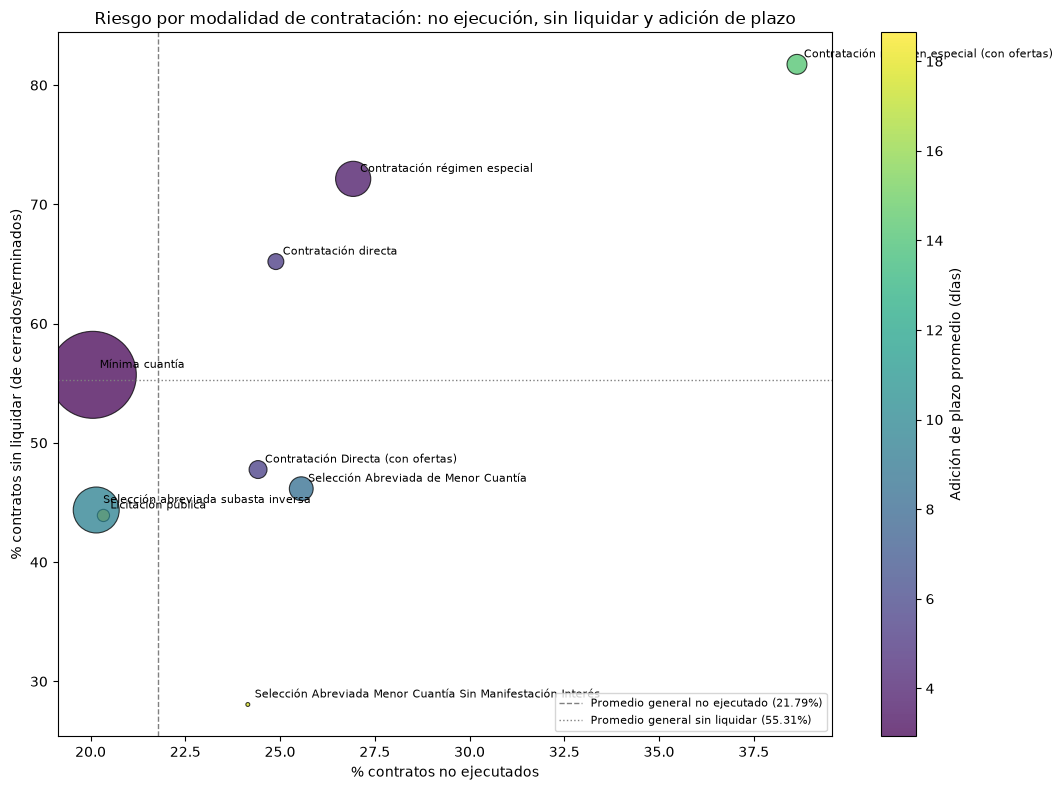

In [10]:
# Construimos una tabla resumen por modalidad con las tres señales de desviación
resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion').agg(
    n_contratos=('modalidad_de_contratacion', 'size'),
    dias_adicionados_promedio=('dias_adicionados', 'mean')
)

resumen_modalidad['pct_no_ejecutado'] = proporciones[True]
resumen_modalidad['pct_sin_liquidar'] = tabla_pct[1]

print(resumen_modalidad.round(2))

# Umbrales de referencia: tasas generales encontradas en el Punto 1
tasa_no_ejecutado_general = 21.79
tasa_sin_liquidar_general = 55.31

fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    resumen_modalidad['pct_no_ejecutado'],
    resumen_modalidad['pct_sin_liquidar'],
    s=resumen_modalidad['n_contratos'] / 30,
    c=resumen_modalidad['dias_adicionados_promedio'],
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.8
)

for modalidad, fila in resumen_modalidad.iterrows():
    ax.annotate(
        modalidad,
        (fila['pct_no_ejecutado'], fila['pct_sin_liquidar']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.axvline(tasa_no_ejecutado_general, color='gray', linestyle='--', linewidth=1, label='Promedio general no ejecutado (21.79%)')
ax.axhline(tasa_sin_liquidar_general, color='gray', linestyle=':', linewidth=1, label='Promedio general sin liquidar (55.31%)')

ax.set_xlabel('% contratos no ejecutados')
ax.set_ylabel('% contratos sin liquidar (de cerrados/terminados)')
ax.set_title('Riesgo por modalidad de contratación: no ejecución, sin liquidar y adición de plazo')
ax.legend(loc='lower right', fontsize=8)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Adición de plazo promedio (días)')

plt.tight_layout()
plt.show()

**Interpretación.**

El gráfico confirma visualmente los hallazgos estadísticos de 3.1 a 3.3. `Contratación régimen especial (con ofertas)` aparece claramente aislada en la esquina superior derecha, con el porcentaje más alto de no ejecución (38.64%) y de cierre sin liquidar (81.74%) de todas las modalidades, lo que la confirma como el foco de riesgo compuesto identificado en la síntesis de 3.4.

`Licitación pública` es un caso distinto e importante. Está por debajo del promedio general en no ejecución (20.34% frente a 21.79%) y en sin liquidar (43.91% frente a 55.31%), pero tiene la adición de plazo promedio más alta de todas las modalidades (18.65 días). Esto confirma visualmente que su riesgo es específico a la dimensión de plazos (hallazgo de 3.1) y no se traslada a las otras dos señales, tal como se planteó en la síntesis.

`Mínima cuantía` concentra el 60% de todos los contratos (n=117753) y se ubica casi exactamente sobre ambas líneas de referencia. Esto no es casualidad, dado su peso en la muestra, es la modalidad que en buena parte define el promedio general, por lo que comparar a las demás modalidades contra ese promedio equivale en parte a compararlas contra `Mínima cuantía` misma.

Una limitación a tener en cuenta es que `Selección Abreviada Menor Cuantía Sin Manifestación Interés` tiene apenas 236 contratos, la burbuja más pequeña del gráfico. Aunque muestra el porcentaje más bajo de cierre sin liquidar (28.06%), ese resultado se apoya en una muestra pequeña y debería tratarse con cautela antes de calificarla como una modalidad de bajo riesgo.

En conjunto, el gráfico muestra que el riesgo de supervisión no se concentra en una sola modalidad de forma homogénea, sino que distintas modalidades destacan en distintas dimensiones. `Contratación régimen especial (con ofertas)` como foco compuesto (no ejecución y sin liquidar), `Licitación pública` como foco específico de adición de plazo, y `Mínima cuantía` como el grupo de referencia dado su volumen. Estos tres perfiles son la base directa del criterio de focalización que se plantea en el Punto 4.

### 3.6 Visualización complementaria: valor del contrato según modalidad y estado de liquidación

Ninguna de las visualizaciones anteriores incluyó `valor_del_contrato`, a pesar de ser uno de los atributos principales del Punto 1 y una variable central para cualquier criterio de focalización de supervisión. Aquí comparamos la distribución del valor del contrato por modalidad, separando entre contratos liquidados y sin liquidar, para ver si el riesgo de no liquidación se concentra en los contratos de mayor o de menor valor dentro de cada modalidad.

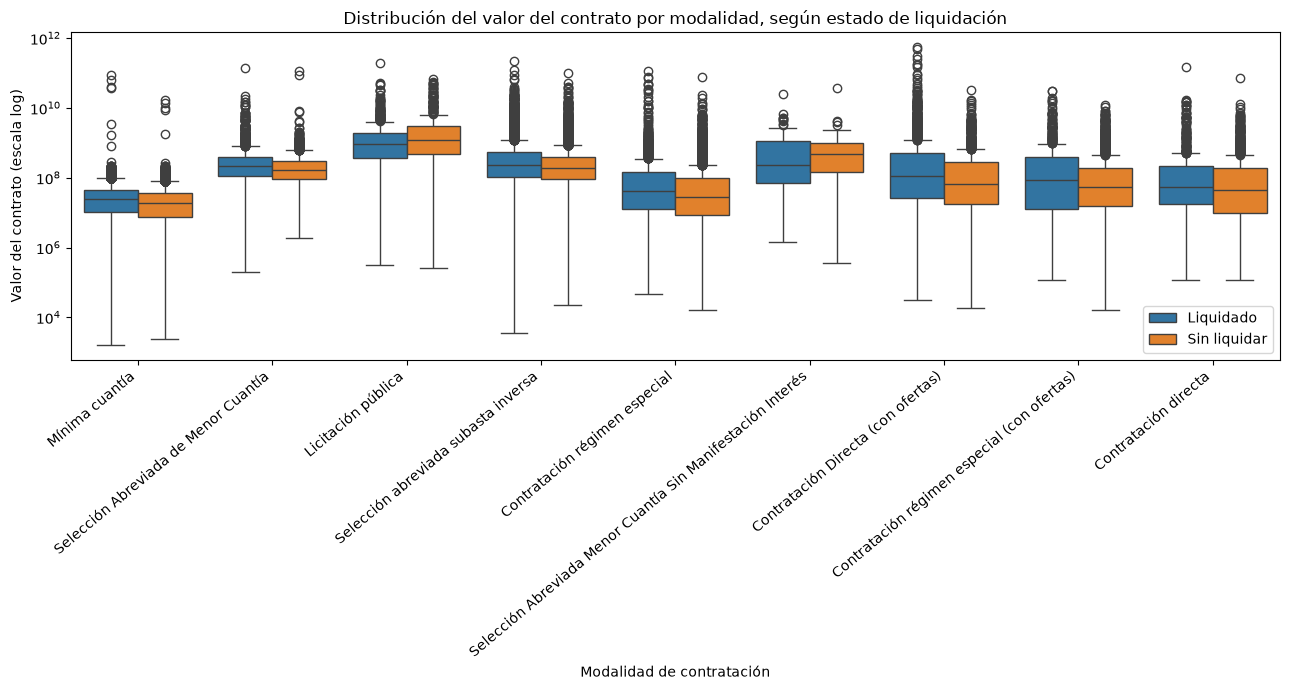

modalidad_de_contratacion                                    sin_liquidar_label
Contratación Directa (con ofertas)                           Liquidado             1.129544e+08
                                                             Sin liquidar          6.633145e+07
Contratación directa                                         Liquidado             5.388650e+07
                                                             Sin liquidar          4.500000e+07
Contratación régimen especial                                Liquidado             4.186535e+07
                                                             Sin liquidar          2.781744e+07
Contratación régimen especial (con ofertas)                  Liquidado             8.740419e+07
                                                             Sin liquidar          5.449862e+07
Licitación pública                                           Liquidado             9.000000e+08
                                                        

In [11]:
datos_valor = df_limpio[
    df_limpio['valor_confiable'] &
    (df_limpio['valor_del_contrato'] > 0) &
    df_limpio['estado_contrato'].isin(['Cerrado', 'Terminado']) &
    df_limpio['liquidacion_confiable']
].copy()

datos_valor['sin_liquidar_label'] = np.where(datos_valor['liquidaci_n'] == 'No', 'Sin liquidar', 'Liquidado')

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=datos_valor,
    x='modalidad_de_contratacion',
    y='valor_del_contrato',
    hue='sin_liquidar_label',
    ax=ax
)
ax.set_yscale('log')
ax.set_xlabel('Modalidad de contratación')
ax.set_ylabel('Valor del contrato (escala log)')
ax.set_title('Distribución del valor del contrato por modalidad, según estado de liquidación')
plt.xticks(rotation=40, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

print(datos_valor.groupby(['modalidad_de_contratacion', 'sin_liquidar_label'])['valor_del_contrato'].median().round(0))

**Interpretación.**

En 7 de las 9 modalidades, la mediana del valor del contrato es más alta entre los contratos liquidados que entre los sin liquidar (por ejemplo, `Contratación Directa (con ofertas)` con 112.95 millones frente a 66.33 millones, o `Contratación régimen especial (con ofertas)` con 87.40 millones frente a 54.50 millones). Esto sugiere que, dentro de la mayoría de modalidades, son los contratos de menor valor los que tienden a quedar sin liquidar, posiblemente porque reciben menor prioridad administrativa de seguimiento frente a los contratos más grandes.

Hay dos excepciones claras a ese patrón. En `Licitación pública`, la mediana de los contratos sin liquidar (1221.05 millones) es mayor que la de los liquidados (900 millones). Como `Licitación pública` ya tiene las medianas de valor más altas de todas las modalidades, varias veces mayores que las de cualquier otra, esto indica que dentro de la modalidad de mayor cuantía son justamente los contratos más costosos los que tienden a quedar sin liquidar, un hallazgo con implicaciones directas para priorizar supervisión por impacto fiscal. La segunda excepción es `Selección Abreviada Menor Cuantía Sin Manifestación Interés` (472.68 millones sin liquidar frente a 227.21 millones liquidados), aunque esta modalidad tiene muy pocos contratos en total (236 según el Punto 1), por lo que esta comparación debe tomarse con cautela dado el tamaño de muestra reducido.

Para `Contratación régimen especial (con ofertas)`, la modalidad que identificamos como foco de riesgo compuesto en 3.4, el patrón sigue la tendencia general (liquidados de mayor valor que sin liquidar). Esto matiza el criterio de focalización, en esta modalidad el riesgo de no liquidación no está concentrado en sus contratos más grandes, por lo que la prioridad de supervisión ahí debería basarse en la modalidad en sí y no adicionalmente en el valor del contrato dentro de ella. En cambio, para `Licitación pública`, el valor del contrato sí es un criterio adicional relevante, dado que ahí el riesgo de no liquidación se concentra en los contratos de mayor valor.

Es importante aclarar que esta es una comparación descriptiva de medianas, no una prueba de hipótesis formal, por lo que no se debe interpretar como evidencia de significancia estadística, sino como un patrón exploratorio que enriquece el criterio de focalización.

### 3.7 ¿El valor del contrato se asocia con el cierre sin liquidar?

A diferencia de 3.6 (donde comparamos el valor dentro de cada modalidad), aquí probamos `valor_del_contrato` de forma directa, sin estratificar por modalidad, contra la bandera `sin_liquidar`.

**Paso 0. Umbral de relevancia práctica.** Dado que el valor del contrato es una variable monetaria muy asimétrica, se define el umbral en términos relativos: se considera relevante una diferencia de al menos 30% entre las medianas de valor de los dos grupos.

**Paso 1. Hipótesis.**
H0: la distribución de `valor_del_contrato` es igual entre contratos liquidados y sin liquidar.
H1: la distribución difiere entre los dos grupos.

In [12]:
umbral_relativo_valor = 0.30
print(f"Se considera relevante una diferencia relativa de al menos {umbral_relativo_valor*100:.0f}% entre las medianas de valor")

# Paso 2. Subconjunto con valor confiable, reutilizando sub_liquidacion de 3.3
sub_valor_liq = sub_liquidacion[sub_liquidacion['valor_confiable'] & (sub_liquidacion['valor_del_contrato'] > 0)].copy()
print(f"Contratos con valor confiable en el subconjunto: {len(sub_valor_liq)}")

grupo_liquidado = sub_valor_liq.loc[sub_valor_liq['sin_liquidar'] == 0, 'valor_del_contrato']
grupo_sin_liquidar = sub_valor_liq.loc[sub_valor_liq['sin_liquidar'] == 1, 'valor_del_contrato']

mediana_liquidado = grupo_liquidado.median()
mediana_sin_liquidar = grupo_sin_liquidar.median()
diferencia_relativa = abs(mediana_liquidado - mediana_sin_liquidar) / mediana_liquidado

print(f"Mediana liquidado: {mediana_liquidado:,.0f}")
print(f"Mediana sin liquidar: {mediana_sin_liquidar:,.0f}")
print(f"Diferencia relativa: {diferencia_relativa*100:.2f}%")

# Paso 3-4. Prueba de Mann-Whitney U
u_stat, p_valor = stats.mannwhitneyu(grupo_liquidado, grupo_sin_liquidar, alternative='two-sided')
print(f"Mann-Whitney U = {u_stat}, p = {p_valor}")

# Paso 5. Tamaño del efecto (correlación rank-biserial)
n1 = len(grupo_liquidado)
n2 = len(grupo_sin_liquidar)
rank_biserial = 1 - (2*u_stat) / (n1 * n2)
print(f"Correlación rank-biserial: {rank_biserial:.4f}")

Se considera relevante una diferencia relativa de al menos 30% entre las medianas de valor
Contratos con valor confiable en el subconjunto: 100905
Mediana liquidado: 39,973,310
Mediana sin liquidar: 28,495,118
Diferencia relativa: 28.71%
Mann-Whitney U = 1453816002.0, p = 0.0
Correlación rank-biserial: -0.1554


**Interpretación.**

La prueba de Mann-Whitney U es significativa (`U` = 1453816002, `p` = 0.0), pero el tamaño del efecto es pequeño (correlación rank-biserial de -0.1554). La diferencia relativa entre las medianas (28.71%, con 39.97 millones en liquidados frente a 28.50 millones en sin liquidar) queda apenas por debajo del umbral de 30% definido en el Paso 0.

Este resultado es consistente con lo encontrado en 3.6. Al no distinguir por modalidad, la prueba global mezcla patrones que van en direcciones distintas, en la mayoría de modalidades los contratos liquidados tienen mayor valor mediano, pero en `Licitación pública` el patrón se invierte. Por esta diferencia entre modalidades, el resultado agregado resume patrones distintos y conviene leerlo junto con el análisis por modalidad. La conclusión práctica es que `valor_del_contrato`, usado solo y sin distinguir modalidad, es un predictor débil y limítrofe de `sin_liquidar`, es más útil como variable secundaria dentro de cada modalidad (como en 3.6) que como criterio de focalización independiente.

### 3.8 ¿El destino del gasto se asocia con presupuesto no ejecutado?

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre categorías.

**Paso 1. Hipótesis.**
H0: la proporción de contratos no ejecutados es independiente de `destino_gasto`.
H1: la proporción depende de `destino_gasto`.

In [13]:
tabla_destino = pd.crosstab(df_limpio['destino_gasto'], df_limpio['no_ejecutado'])
proporciones_destino = (pd.crosstab(df_limpio['destino_gasto'], df_limpio['no_ejecutado'], normalize='index') * 100).round(2)

print(tabla_destino)
print()
print(proporciones_destino)

chi2_d, p_d, dof_d, esperadas_d = stats.chi2_contingency(tabla_destino)
print()
print(f"Chi2 = {chi2_d}, p = {p_d}, grados de libertad = {dof_d}")
print(f"Minima frecuencia esperada: {esperadas_d.min()}")

n_d = tabla_destino.values.sum()
k_min_d = min(tabla_destino.shape) - 1
cramers_v_d = (chi2_d / (n_d * k_min_d)) ** 0.5
print(f"Cramér V: {cramers_v_d:.4f}")

no_ejecutado    False  True 
destino_gasto               
Funcionamiento  87495  29602
Inversión       65597  12786
No Definido       221    158
No aplica         283    249

no_ejecutado    False  True 
destino_gasto               
Funcionamiento  74.72  25.28
Inversión       83.69  16.31
No Definido     58.31  41.69
No aplica       53.20  46.80

Chi2 = 2500.296677661844, p = 0.0, grados de libertad = 3
Minima frecuencia esperada: 82.58680387594136
Cramér V: 0.1128


**Interpretación.**

El chi-cuadrado es significativo (`chi2` = 2500.30, `df` = 3, `p` = 0.0), con el supuesto de frecuencia esperada mínima cumplido (82.59). El Cramér's V es 0.1128, un efecto pequeño, aunque ligeramente más fuerte que el de modalidad frente a `no_ejecutado` en 3.2 (0.0931).

Sin embargo, el contraste más grande no está entre las categorías sustantivas, sino entre estas y las categorías indefinidas. `No aplica` (46.80%) y `No Definido` (41.69%) tienen tasas de no ejecución mucho más altas que `Funcionamiento` (25.28%) e `Inversión` (16.31%). Esto sugiere que un registro de destino del gasto incompleto o mal clasificado y un contrato sin ejecutar presupuesto podrían ser dos síntomas del mismo problema administrativo subyacente, más que una relación causal directa entre destino del gasto y no ejecución. Entre las dos categorías sustantivas, la diferencia es de apenas 8.97 puntos porcentuales, por debajo del umbral de 10 puntos definido en el Paso 0.

En conclusión, `destino_gasto` no aporta una diferencia prácticamente relevante entre gasto de funcionamiento e inversión, pero la alta tasa de no ejecución en los registros sin destino de gasto definido es en sí misma una señal de calidad de datos que vale la pena reportar por separado, no como criterio de focalización de destino del gasto.

### 3.9 ¿El sector se asocia con el cierre sin liquidar?

Se excluye la categoría `No Definido` de `sector` (9 contratos en todo el dataset, 0.0046% del total), dado que es demasiado pequeña para cumplir el supuesto de frecuencia esperada mínima del chi-cuadrado, y en la práctica es una categoría de dato faltante más que un sector real.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre sectores.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente del sector.
H1: la proporción depende del sector.

In [14]:
sub_sector = sub_liquidacion[sub_liquidacion['sector'] != 'No Definido'].copy()
print(f"Contratos tras excluir sector 'No Definido': {len(sub_sector)}")

tabla_sector = pd.crosstab(sub_sector['sector'], sub_sector['sin_liquidar'])
proporciones_sector = (pd.crosstab(sub_sector['sector'], sub_sector['sin_liquidar'], normalize='index') * 100).round(2)

print(tabla_sector)
print()
print(proporciones_sector[1].sort_values(ascending=False))

chi2_s, p_s, dof_s, esperadas_s = stats.chi2_contingency(tabla_sector)
print()
print(f"Chi2 = {chi2_s}, p = {p_s}, grados de libertad = {dof_s}")
print(f"Minima frecuencia esperada: {esperadas_s.min()}")

n_s = tabla_sector.values.sum()
k_min_s = min(tabla_sector.shape) - 1
cramers_v_s = (chi2_s / (n_s * k_min_s)) ** 0.5
print(f"Cramér V: {cramers_v_s:.4f}")

Contratos tras excluir sector 'No Definido': 101054
sin_liquidar                                            0     1
sector                                                         
Ambiente y Desarrollo Sostenible                     1767  2153
Ciencia Tecnología                                     29   292
Cultura                                               623   856
Educación Nacional                                   1476  2955
Hacienda y Crédito Público                            781   611
Inclusión Social y Reconciliación                     145   253
Industria                                             370   611
Información Estadística                                50   181
Inteligencia Estratégica y Contrainteligencia          23     8
Ley de Justicia                                      2486  6190
Minas y Energía                                       147   259
No aplica/No pertenece                               4658  7153
Planeación                                          

**Interpretación.**

El chi-cuadrado es altamente significativo (`chi2` = 8008.96, `df` = 24, `p` = 0.0), con el supuesto de frecuencia esperada mínima cumplido, aunque cerca del límite (13.85, dado que `Inteligencia Estratégica y Contrainteligencia` es un sector pequeño). El Cramér's V es 0.2815, el efecto más fuerte de todo el Punto 3, muy por encima del máximo anterior (0.1748 de modalidad frente a `sin_liquidar`).

Los porcentajes de `sin_liquidar` van desde 25.81% (`Inteligencia Estratégica y Contrainteligencia`) hasta 90.97% (`Ciencia Tecnología`), un rango de 65.16 puntos porcentuales, muy por encima del umbral de 10 puntos. Dos sectores de alto volumen muestran tasas elevadas de forma robusta, no como artefacto de muestra pequeña, `Ley de Justicia` (8676 contratos, 71.35% sin liquidar) y `Salud y Protección Social` (11097 contratos, 70.67% sin liquidar). En el extremo opuesto, `defensa` es el sector de mayor volumen entre los contratos cerrados o terminados (23539 contratos) y tiene una tasa notablemente baja (33.10%), muy por debajo del promedio general de 55.31%, lo que sugiere procesos de cierre administrativo más disciplinados en ese sector. Sectores como `Ciencia Tecnología` (90.97%) e `Información Estadística` (78.35%) tienen las tasas más altas, pero con muestras más pequeñas (321 y 231 contratos), por lo que deben interpretarse con más cautela que los hallazgos de `Ley de Justicia` y `Salud y Protección Social`.

En conjunto, `sector` es el predictor categórico más fuerte de cierre sin liquidar encontrado en todo este análisis, por encima de `modalidad_de_contratacion`.

### 3.10 Visualización complementaria: riesgo por sector

`Sector` resultó ser el predictor individual más fuerte de cierre sin liquidar encontrado en el Punto 3 (Cramér's V = 0.2815), pero hasta ahora no tenía ninguna representación visual. Aquí se muestra el porcentaje de contratos sin liquidar por sector, ordenado de mayor a menor, coloreando cada barra según su número de contratos para distinguir hallazgos robustos de hallazgos basados en muestras pequeñas.

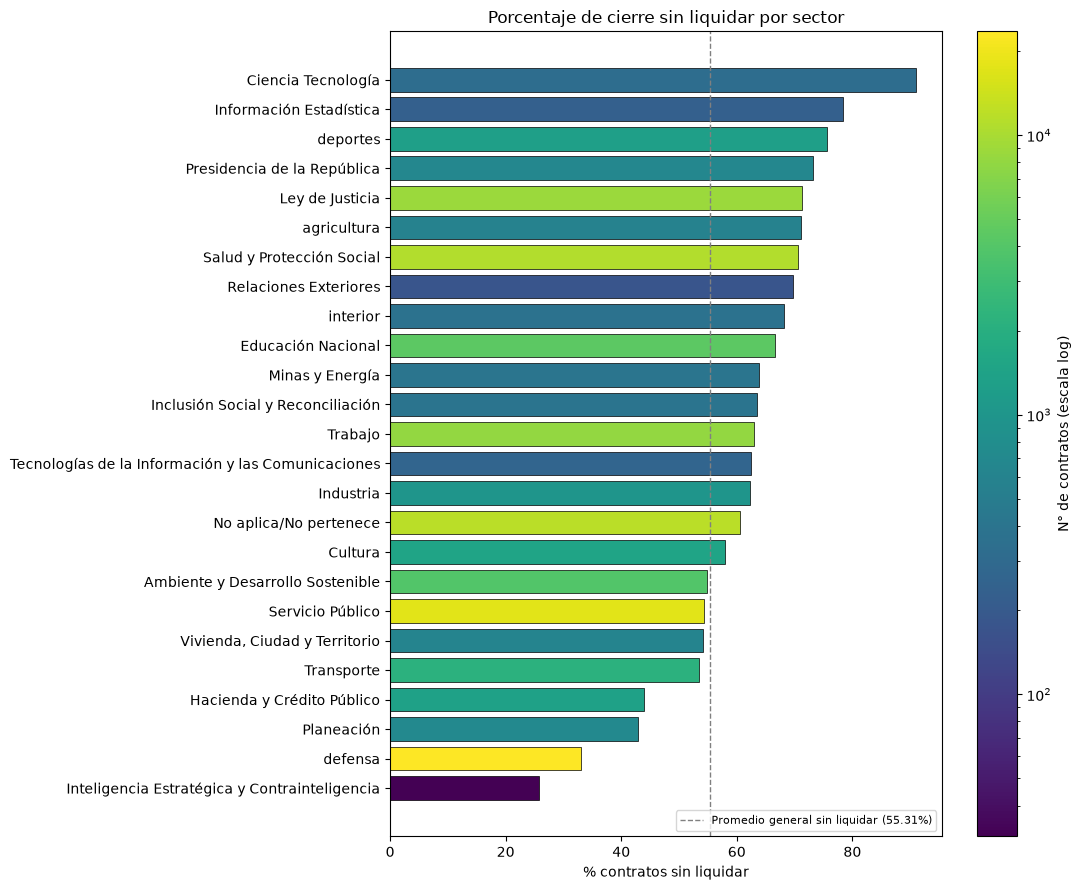

                                                    n_contratos  \
sector                                                            
Ciencia Tecnología                                          321   
Información Estadística                                     231   
deportes                                                   1271   
Presidencia de la República                                 668   
Ley de Justicia                                            8676   
agricultura                                                 577   
Salud y Protección Social                                 11097   
Relaciones Exteriores                                       178   
interior                                                    374   
Educación Nacional                                         4431   
Minas y Energía                                             406   
Inclusión Social y Reconciliación                           398   
Trabajo                                                    793

In [15]:
resumen_sector = sub_sector.groupby('sector').agg(
    n_contratos=('sector', 'size')
)
resumen_sector['pct_sin_liquidar'] = tabla_sector[1] / (tabla_sector[0] + tabla_sector[1]) * 100
resumen_sector = resumen_sector.sort_values('pct_sin_liquidar', ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))

norm = plt.matplotlib.colors.LogNorm(vmin=resumen_sector['n_contratos'].min(), vmax=resumen_sector['n_contratos'].max())
colores = plt.cm.viridis(norm(resumen_sector['n_contratos']))

barras = ax.barh(resumen_sector.index, resumen_sector['pct_sin_liquidar'], color=colores, edgecolor='black', linewidth=0.5)

ax.axvline(55.31, color='gray', linestyle='--', linewidth=1, label='Promedio general sin liquidar (55.31%)')
ax.set_xlabel('% contratos sin liquidar')
ax.set_title('Porcentaje de cierre sin liquidar por sector')
ax.legend(loc='lower right', fontsize=8)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('N° de contratos (escala log)')

plt.tight_layout()
plt.show()

print(resumen_sector.sort_values('pct_sin_liquidar', ascending=False).round(2))

**Interpretación.**

El gráfico deja claro que el riesgo de cierre sin liquidar por sector no está relacionado con el volumen de contratos. Dos sectores de alto volumen se ubican claramente por encima del promedio general (55.31%), `Ley de Justicia` (8676 contratos, 71.35%) y `Salud y Protección Social` (11097 contratos, 70.67%), lo que los convierte en los hallazgos más sólidos y accionables de todo el análisis, porque combinan una tasa alta con una muestra grande.

`defensa`, en cambio, es el sector de mayor volumen entre los contratos cerrados o terminados (23539 contratos) y se ubica muy por debajo del promedio (33.10%), justo al lado de `Inteligencia Estratégica y Contrainteligencia` (25.81%, aunque este último con apenas 31 contratos). `Servicio Público`, el segundo sector de mayor volumen entre los cerrados o terminados (17594 contratos), se ubica casi exactamente sobre la línea de referencia (54.30%), un riesgo cercano al promedio, ni alto ni bajo.

Los porcentajes más altos del gráfico, `Ciencia Tecnología` (90.97%), `Información Estadística` (78.35%), `deportes` (75.61%) y `Presidencia de la República` (73.20%), corresponden a sectores de volumen bajo (321, 231, 1271 y 668 contratos respectivamente). Aunque estos porcentajes son llamativos, deben interpretarse con más cautela que los de `Ley de Justicia` y `Salud y Protección Social`, dado su menor tamaño de muestra.

En conjunto, esta visualización refuerza que `sector` no es solo el predictor estadísticamente más fuerte, sino que además identifica candidatos concretos y robustos para la focalización de supervisión, en particular `Ley de Justicia` y `Salud y Protección Social`.

### 3.11 Síntesis: hacia un criterio compuesto de focalización

Al incorporar los cuatro factores analizados (modalidad de contratación, valor del contrato, destino del gasto y sector), el hallazgo más importante es que `sector` es el predictor individual más fuerte encontrado en todo el Punto 3 (Cramér's V = 0.2815 frente a `sin_liquidar`), superando a `modalidad_de_contratacion` (Cramér's V = 0.1748). Esto indica que, si se debe elegir un solo eje para focalizar supervisión por cierre sin liquidar, el sector es más informativo que la modalidad de contratación.

`Ley de Justicia` y `Salud y Protección Social` destacan como sectores de alto volumen y alto riesgo de cierre sin liquidar (71.35% y 70.67% respectivamente, muy por encima del promedio general de 55.31%). `defensa`, en cambio, pese a ser el sector de mayor volumen entre los contratos cerrados o terminados, muestra el riesgo más bajo entre los sectores grandes (33.10%).

`Contratación régimen especial (con ofertas)` se mantiene como el foco transversal a nivel de modalidad, con riesgo elevado tanto en no ejecución como en cierre sin liquidar. `Licitación pública` sigue siendo el foco específico de adición de plazo y de contratos sin liquidar de alto valor.

`destino_gasto` no mostró una diferencia prácticamente relevante entre gasto de funcionamiento e inversión (8.97 puntos, por debajo del umbral de 10), pero identificó una señal de calidad de datos relevante, los registros con destino de gasto indefinido tienen tasas de no ejecución mucho más altas, lo que sugiere un problema de documentación asociado.

`valor_del_contrato`, evaluado de forma independiente sin distinguir modalidad, resultó ser un predictor débil de `sin_liquidar` (correlación rank-biserial de apenas -0.1554), lo que confirma que su valor como criterio de focalización está en combinarlo con otras variables (como se vio en 3.6 dentro de cada modalidad), no en usarlo solo.

Es importante aclarar que estos cuatro factores se probaron de forma independiente entre sí, no se evaluaron sus posibles interacciones (por ejemplo, si el riesgo de `Ley de Justicia` se concentra además en una modalidad específica). Esto se documenta como limitación en el Punto 4.

## 4. Generación de resultados

### 4.1 Contexto y objetivo

Este documento resume los resultados del análisis realizado sobre 196391 contratos de bienes y suministros registrados en SECOP II entre 2019 y 2025. El objetivo es proponer criterios de focalización de supervisión basados en evidencia estadística, evaluando cuatro factores disponibles en los datos, la modalidad de contratación, el valor del contrato, el destino del gasto, y el sector, frente a tres señales de desviación identificadas en el Punto 1, adición de plazo, presupuesto no ejecutado, y cierre sin liquidar.

### 4.2 Hallazgos generales

En el Punto 1 se identificaron tres señales de desviación relevantes sobre el total de contratos. El 9.51% de los contratos tuvo adición de plazo, el 21.79% quedó cerrado o terminado sin ejecutar presupuesto, y el 55.31% de los contratos cerrados o terminados quedó sin liquidar.

En el Punto 3 se contrastaron cuatro factores frente a estas señales. `Sector` resultó ser el predictor más fuerte encontrado en todo el análisis (Cramér's V de 0.2815 frente a cierre sin liquidar), seguido de `modalidad_de_contratacion` (Cramér's V de 0.1748 en su mejor resultado, también frente a cierre sin liquidar), y de `destino_gasto` (Cramér's V de 0.1128 frente a no ejecución, aunque impulsado en buena parte por categorías de registro indefinido más que por una diferencia sustantiva entre gasto de funcionamiento e inversión). `Valor_del_contrato`, evaluado de forma independiente sin distinguir por modalidad, resultó ser el factor más débil (correlación rank-biserial de apenas -0.1554 frente a cierre sin liquidar), su relación con el riesgo depende de con qué otra variable se combine, no funciona como criterio aislado.

### 4.3 Criterios de focalización propuestos

**Foco principal, por sector.** `Ley de Justicia` (8676 contratos, 71.35% sin liquidar) y `Salud y Protección Social` (11097 contratos, 70.67% sin liquidar) son los hallazgos más sólidos de todo el análisis, combinan una tasa muy por encima del promedio general (55.31%) con un volumen de contratos suficientemente grande para que la estimación sea confiable. Se recomienda que estos dos sectores sean el primer criterio de focalización. En contraste, `defensa`, pese a ser el sector de mayor volumen entre los contratos cerrados o terminados (23539 contratos), tiene una tasa de sin liquidar notablemente baja (33.10%), y `Servicio Público`, el segundo en volumen entre los cerrados o terminados (17594 contratos), se ubica prácticamente en el promedio general (54.30%), ninguno de los dos debería priorizarse por esta señal.

**Foco secundario, por modalidad de contratación.** `Contratación régimen especial (con ofertas)` se mantiene como un foco transversal, con el porcentaje más alto de no ejecución (38.64%) y de cierre sin liquidar (81.74%) entre todas las modalidades. `Licitación pública` es un foco distinto y específico, no destaca en no ejecución ni en sin liquidar, pero tiene la adición de plazo promedio más alta (18.65 días) y concentra sus contratos sin liquidar en los de mayor valor, por lo que su supervisión debería enfocarse en plazos y en los contratos de mayor cuantía dentro de esta modalidad.

**El valor del contrato como criterio secundario, no independiente.** Al probarlo de forma aislada, `valor_del_contrato` no superó el umbral de relevancia práctica definido (diferencia relativa de 28.71% entre medianas, frente a un umbral de 30%), y su relación con el riesgo cambia de dirección según la modalidad, en `Licitación pública` los contratos sin liquidar son los más costosos, mientras que en la mayoría de las demás modalidades ocurre lo contrario. Por esto, el valor del contrato debería usarse como un filtro adicional dentro de una modalidad o sector ya identificado como riesgoso, no como un criterio de focalización por sí solo.

**Destino del gasto como señal de calidad de datos, no como criterio de focalización.** La diferencia sustantiva entre `Funcionamiento` (25.28% no ejecutado) e `Inversión` (16.31%) fue de apenas 8.97 puntos porcentuales, por debajo del umbral definido. Sin embargo, los registros con destino de gasto sin definir mostraron una tasa de no ejecución mucho más alta (41.69% y 46.80%), lo que sugiere que un registro incompleto en este campo podría ser en sí mismo un indicador de riesgo administrativo, y valdría la pena que la oficina de control interno lo revise como una alerta de calidad de datos más que como un criterio de focalización por tipo de gasto.

### 4.4 Limitaciones del análisis

Los cuatro factores, modalidad, valor del contrato, destino del gasto y sector, se probaron de forma independiente entre sí frente a cada señal de desviación. No se evaluaron sus interacciones, por ejemplo si el riesgo de `Ley de Justicia` se concentra además en una modalidad o un rango de valor específico, ni se ajustó un modelo multivariado (como una regresión logística) que controle por todas las variables al mismo tiempo. Es posible que parte de la asociación observada en cada prueba individual se explique por otra variable no incluida en ese análisis puntual.

Con un tamaño de muestra de casi 200000 contratos, casi cualquier diferencia entre grupos resulta estadísticamente significativa, incluso cuando el tamaño del efecto es pequeño. Por esta razón, todas las conclusiones se basaron en umbrales de relevancia práctica definidos antes de cada prueba, y no únicamente en el valor p. La prueba de `sector` frente a cierre sin liquidar cumplió el supuesto de frecuencia esperada mínima, pero de forma ajustada (13.85, cerca del límite de 5), dado que algunos sectores como `Inteligencia Estratégica y Contrainteligencia` tienen muestras pequeñas (31 contratos en total).

Las banderas `no_ejecutado` y `sin_liquidar` son proxies construidos a partir de reglas simples, y las categorías `No aplica` y `No Definido` de `destino_gasto`, así como `No Definido` de `sector` (excluida de la prueba de 3.9 por tener solo 9 contratos), probablemente reflejan problemas de registro o clasificación incompleta más que una categoría sustantiva, lo que limita la interpretación de esos resultados específicos.

Finalmente, este análisis identifica asociaciones estadísticas y patrones descriptivos, no relaciones causales. Cualquier criterio de focalización propuesto aquí debería validarse con conocimiento del proceso administrativo real antes de implementarse como política de supervisión.